## __100 top streamed songs on Spotify__

Jako dataset do projektu wybrałam zbiór opisujący 100 najpopularniejszych piosenek wszechczasów na Spotify. Zbiór zawiera dane na temat samych utworów, takie jak liczba odtworzeń czy tytuły, ale także informacje o gatunku muzycznym, artyście czy treści piosenki. Zbiór pobrałam w formacie csv ze strony Kaggle (link: https://www.kaggle.com/datasets/emanfatima2/spotify-global-hits-and-artist-analytics). Wybrałam ten dataset ze względu na moje zainteresowania, jestem ciekawa co czyni daną piosnkę hitem, a w trakcie prostej analizy mogę wyciągnąć wiele wniosków na ten temat. 

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Importuje przydatne biblioteki do pracy z danymi i do tworzenia wizualizacji

In [88]:
df = pd.read_csv('spotify_alltime_songs.csv', na_values=['?', 'NA', '', ' '], index_col='alltime_rank')
df.head(10)

,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
alltime_rank,,,,,,,,,,,,,
1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100


Wczytuję dane do dataframe, relatywna ścieżka do pliku csv, parametr na_values - aby było jasne co jest uznawane za wartości brakujące, oraz index_col - tutaj za index uznamy ranking piosenki, są one ponumerowane od 1 do 100, rankingi są unikalne, więc kolumna nadaje się na indeks. Następnie wczutuję 10 pierwszych wierszy df, aby sprawdzić czy wszystko zostało poprawnie wczytane. 

In [89]:
df.columns #sprawdzam kolumny w df

Index(['song_title', 'artist', 'total_streams_billions', 'primary_genre',
       'bpm', 'release_year', 'artist_country', 'explicit', 'danceability',
       'energy', 'valence', 'acousticness', 'dataset_part'],
      dtype='str')

In [90]:
df.shape # sprawdzam strukturę danych, df posiada 100 wierszy oraz 13 kolumn

(100, 13)

In [91]:
df.dtypes #sprawdzamy typy kolumn

song_title                    str
artist                        str
total_streams_billions    float64
primary_genre                 str
bpm                         int64
release_year                int64
artist_country                str
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part                  str
dtype: object

In [92]:
df.describe() #szybko sprawdzam strukturę, statystyki dla danych atrybutów

,total_streams_billions,bpm,release_year,danceability,energy,valence,acousticness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.524600,115.780000,2016.800000,0.613500,0.636100,0.550600,0.153400
std,0.851432,30.540776,7.063922,0.142888,0.163824,0.238623,0.164637
min,1.400000,62.000000,1985.000000,0.300000,0.260000,0.070000,0.000000
25%,1.735000,95.000000,2016.000000,0.520000,0.527500,0.387500,0.020000
50%,2.435000,107.000000,2018.500000,0.620000,0.650000,0.565000,0.085000
75%,3.167500,139.000000,2021.000000,0.725000,0.775000,0.732500,0.245000
max,5.260000,191.000000,2024.000000,0.900000,0.960000,0.960000,0.760000


In [225]:
df.groupby('primary_genre').size()

primary_genre
Acoustic Pop      1
Afrobeats/Pop     2
Alt Rock          7
Art Pop           1
Art Rock          1
Blues Rock        1
Country/Pop       1
EDM/Pop           4
Electropop        1
Emo Rap           1
Folk Pop          1
Funk/Pop          2
Grunge            1
Hip-Hop           7
Hip-Hop/Pop       2
Holiday Pop       1
Indie Folk        2
Indie Pop        12
Indie Rock        2
K-Pop/Pop         1
Latin Pop         2
Nu-Disco          1
Pop              17
Pop Punk          3
Pop Rap           1
Pop Rock          6
Pop/Country       1
Pop/Dancehall     1
Pop/Folk          1
Pop/Funk          1
Pop/R&B           1
Pop/Soul          1
R&B               1
R&B/Pop           2
R&B/Soul          1
Reggaeton         1
Soul/R&B          1
Synth-Pop         6
Trap Pop          1
dtype: int64

In [ ]:
rock_df = df[df['primary_genre'] == 'Pop']

df.loc[
    rock_df['total_streams_billions'].idxmin(),
    'song_title'
]#sprawdzam głównie z ciekawości najmniej popularną piosenkę Pop na liście

'Attention'

Po zapoznaniu się ze strukturą danych w zbiorze zabieram się za wartości brakujące, najpierw sprawdzam czy w zbiorze są wartości brakujące.

In [93]:
df.isna().sum() #sumujemy boole, w każdej kolumnie jest suma 100(1-nie na, 0 - na), co oznacza że nie ma  żadnych wartości brakujących,
#więc nie będzie potrzebne ich zastępowanie lub usuwanie wierszy. Gdyby były np w kolumnach to możnaby skorzystac np z fillna()

song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64

<Axes: >

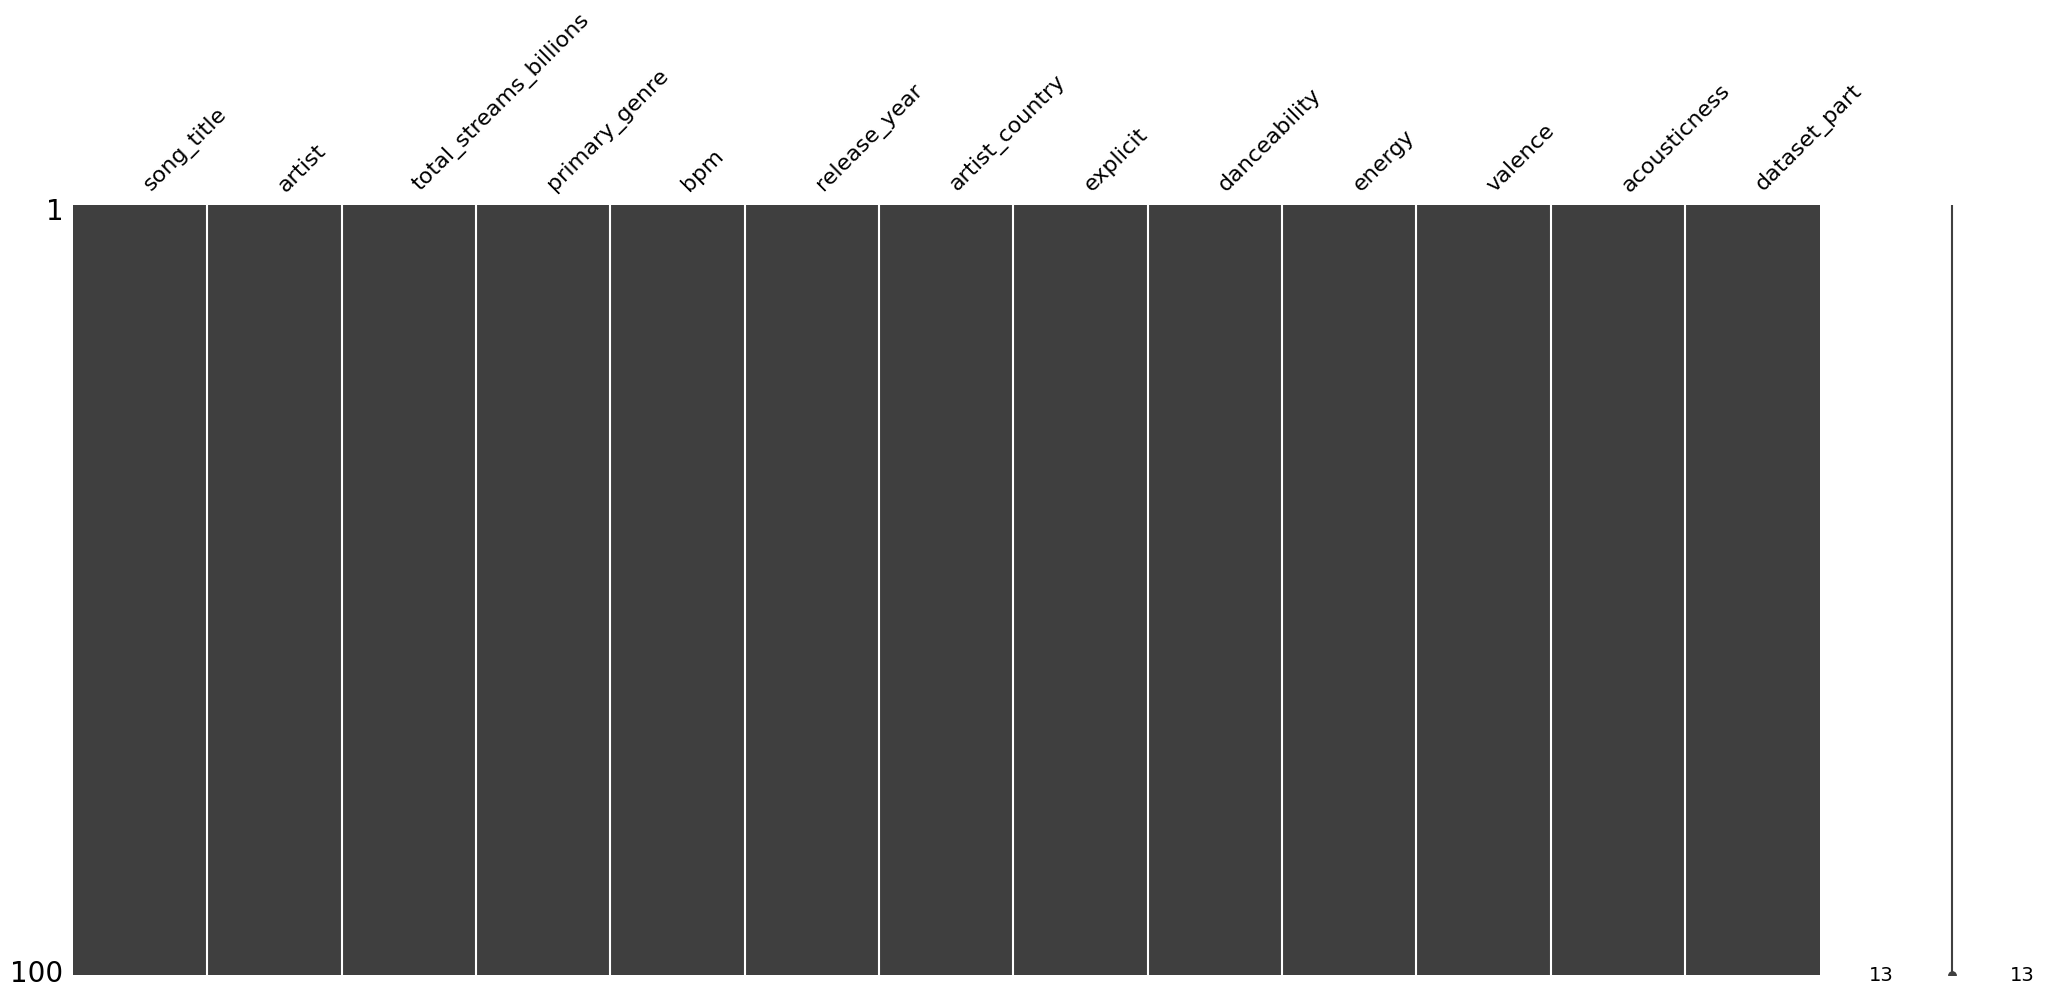

In [94]:
import missingno as msno
msno.matrix(df) #tutaj biblioteka, którą znalazłam jakiś czas temu, przydatne do wizualizacji braków, w moim przypadku jednak nie jest do końca potrzebna

In [ ]:
#ostatnia kolumna nie jest do niczego potrzebna, więc ją usuwamy. w zestawie było kilka datasetów,
# sama kolumna jest do identyfikacji z którego zbioru jest dany wiersz, tutaj wszystko jest z tego samego, więc można ją bezpiecznie usunąć
df = df.drop('dataset_part', axis=1, errors='ignore') # ignore żeby nie wyświetliło błędu, jeśli kolumna nie istnieje
df.head() #sprawdzam czy kolumna została usunięta

,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness
alltime_rank,,,,,,,,,,,,
1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00
2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08
3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29
4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15
5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09


In [171]:
font = {'family': 'serif',
        'fontname': 'Satoshi',
        'color':  '#04061f',
        'weight': 'normal'
        }

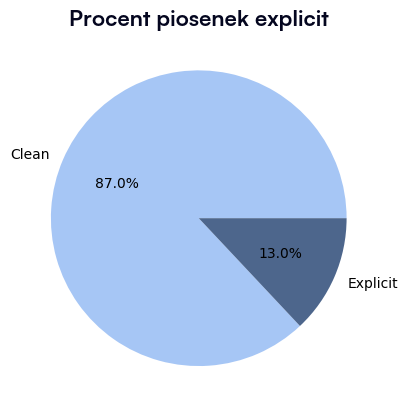

In [ ]:
counts = df['explicit'].value_counts()
counts.plot(kind='pie', labels=['Clean', 'Explicit'], autopct='%1.1f%%', colors=['#a6c6f5', '#4d668c'])
plt.ylabel('') 
plt.title('Procent piosenek explicit', fontdict=font, size=16, fontweight= 'bold')
plt.show()
#tutaj sprawdzam ile piosenek ma tekst zaklasyfikowany jako explicit (zawierający treści nieodpowiednie) , plus szybki wykres kołowy (tylko 2 kategorie więc nie ma problemu z clutter)


In [97]:
# filtrujemy tylko explicit, liczymy i sortujemy
explicit_songs = df[df['explicit']]
counts = explicit_songs['artist_country'].value_counts()
print(counts) #mamy malutki series z wynikami, aż 10 z 13 piosenek o tekście kategoryzowanym jako explicit wykonuje artysta pochodzący z USA

artist_country
USA          10
Canada        2
Australia     1
Name: count, dtype: int64


C:\Users\kkarg\AppData\Local\Temp\ipykernel_8032\3060196242.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=countries,


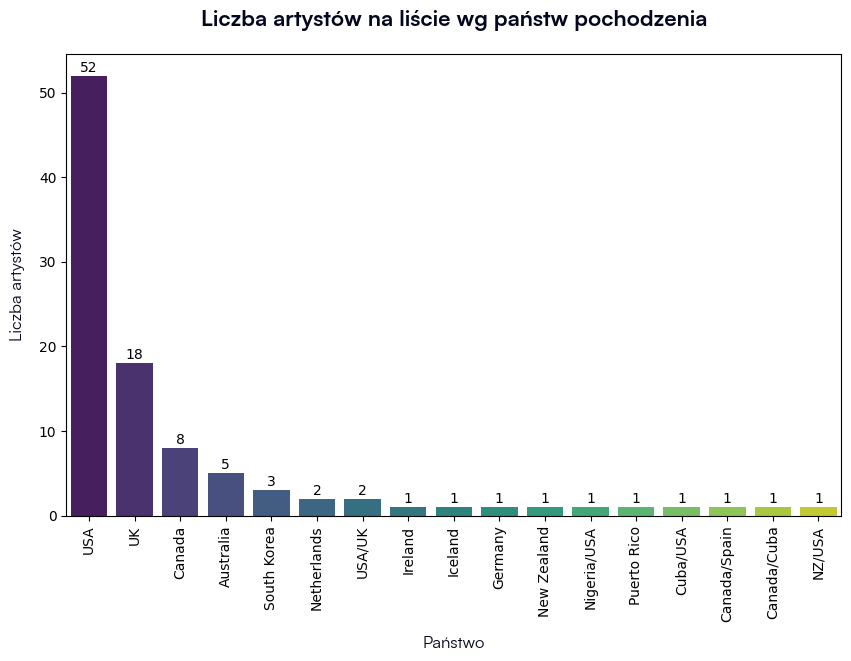

In [ ]:
#tutaj sprawdzamy ile wykonawców pochodzi z danego państwa
countries = (df.groupby('artist_country')
             .size()
             .reset_index(name='count')
             .sort_values(by='count', ascending=False))
plt.figure(figsize=(10,6))
ax = sns.barplot(data=countries,
             x='artist_country',
             y='count',
            legend=False,
            palette='viridis')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,  
        height + 0.5,                 
        int(height),                  
        ha='center'                  
    )#tutaj przyznaję się do wykorzystania AI, nie byłam pewna jak wstawić value na wykresie :(
plt.title('Liczba artystów na liście wg państw pochodzenia', fontdict=font, size=16, pad=20, fontweight='bold', loc='center')
plt.xlabel('Państwo', fontdict=font, size=12, labelpad=10)
plt.ylabel('Liczba artystów', fontdict=font, size=12, labelpad=10)
plt.xticks(rotation=90)
plt.show()

In [140]:
countries[countries['artist_country'].str.contains('US|United States', regex=True)]['count'].sum() #tu sprawdzam ile artystów pochodzi z USA, regex dla wyrażenia regularnego, aby nie pominąć 
# żadnej wariacji nazwy. Robię to w celu sprawdzenia jaki jest stosunek artystów z USA do inncyh państw. Łącznie jest 57 artystów z USA, czyli ponad połowa listy. 
print(f'{((13 / (countries[countries['artist_country'].str.contains('US|United States', regex=True)]['count'].sum())) * 100):.2f}% piosenek artystów z USA zawiera treści explicit')

print(f"W porównaniu {((2 / (countries[countries['artist_country'] == 'Canada']['count'].iloc[0])) * 100):.0f}% piosenek z Kanady miało treści explicit") #iloc żeby wyciągnąc wartośc z series

22.81% piosenek artystów z USA zawiera treści explicit
W porównaniu 25% piosenek z Kanady miało treści explicit


Dzięki takiemu porównaniu możemy zobaczyć że piosenki z USA nie są bardziej wulgarne niż te z innych państw, z powodu ogromnej przewagi liczby piosenek z tego kraju na liście, także liczba piosenek explicit jest duża, jednak w porównaniu do Kanady, drugiego najpopularniejszego państwa, mniejsza częśc piosenek zawiera treści explicit.

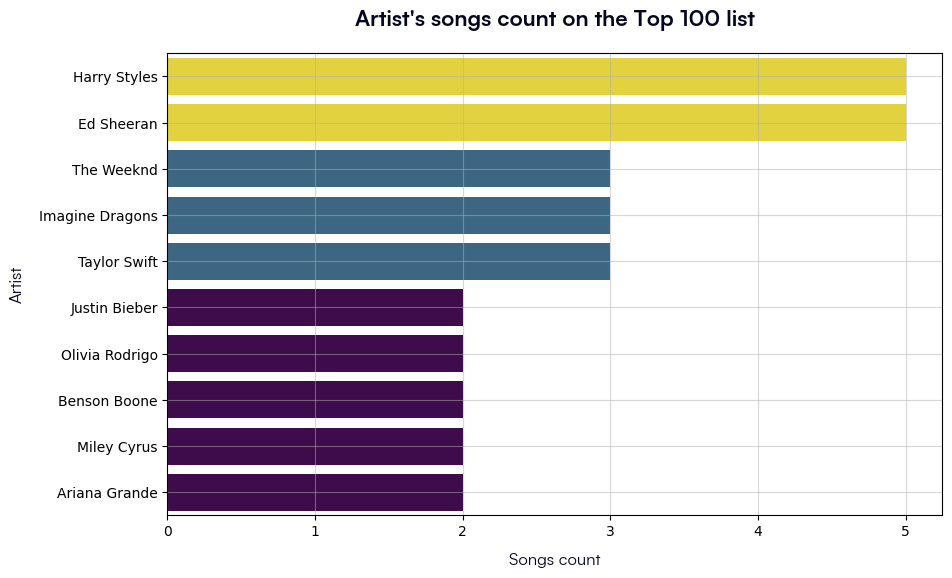

In [204]:
by_artist = (df.groupby(by='artist')['song_title']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index())
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=by_artist, x='song_title', y='artist', palette='viridis', hue='song_title', legend=False)
plt.xlabel('Songs count', fontdict=font, size=12, labelpad=10)
plt.ylabel('Artist', fontdict=font, size=12, labelpad=10)
plt.title("Artist's songs count on the Top 100 list", fontdict=font, size=16, pad=20, fontweight='bold', loc='center')
plt.grid(alpha=0.5)
plt.show(ax)


Na powyższym wykresie pogrupowałam piosenki po artystach i stworzyłam wykres 10 najpopularniejszych artystów, jest to prosty horyzontalny barchart zliczający ilośc piosenek danego artysty na liście top 100. Zmieniłam rozmiar pola, na standardowe, przynajmniej w moim odczuciu 10,6; opisałam osie oraz stworzyłam tytuł. Wcześniej stworzyłam słownik ze stylem dla tekstu, rozmiar i padding ustawiłam osobno dla labels i osobno dla title. Na koniec dodałam grid, jednak na tym wykresie nie jest on specjalnie potrzebny. 

In [241]:
df[df['artist'].str.contains('Harry Styles|Ed Sheeran')][['song_title', 'artist']].sort_values(by=['artist','alltime_rank']) #sprawdzamy piosenki najpopularniejszych artystów i ich miejsce w rankingu

,song_title,artist
alltime_rank,,
2,Shape of You,Ed Sheeran
13,Perfect,Ed Sheeran
54,Bad Habits,Ed Sheeran
62,Photograph,Ed Sheeran
68,Thinking Out Loud,Ed Sheeran
12,Watermelon Sugar,Harry Styles
21,As It Was,Harry Styles
52,Falling,Harry Styles
84,Sign of the Times,Harry Styles


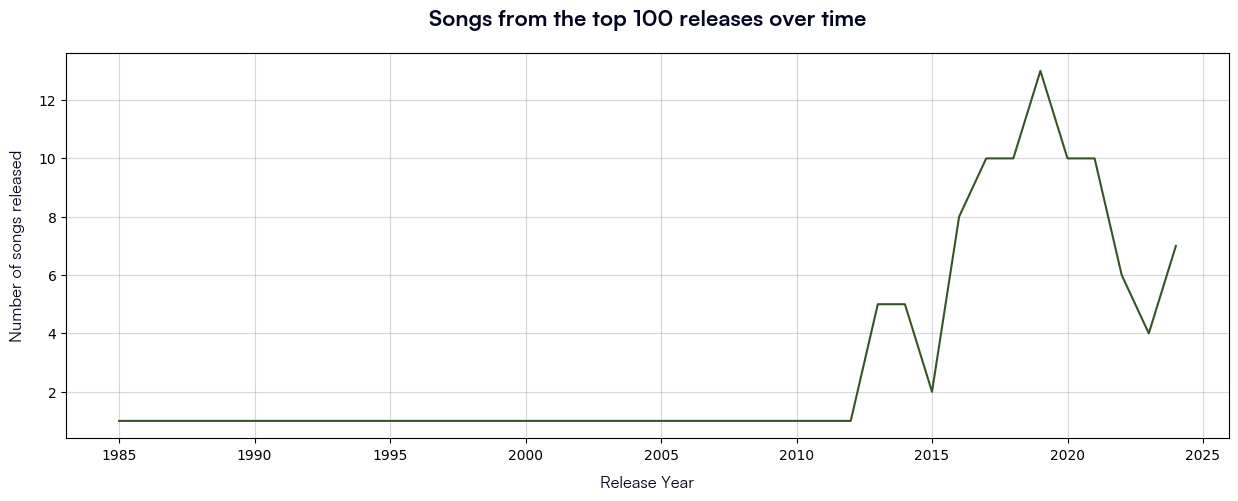

In [208]:
df.groupby('release_year').size().reset_index(name='count').plot(kind='line', x='release_year', legend=False, figsize=(15, 5), color='#365428')
plt.xlabel('Release Year', fontdict=font, size=12, labelpad=10)
plt.ylabel('Number of songs released', fontdict=font, size=12, labelpad=10)
plt.title('Songs from the top 100 releases over time', fontdict=font, size=16, pad=20, fontweight='bold', loc='center')
plt.grid(alpha=0.5)
plt.show()

Na powyższym wykresie widać że znaczna część piosenek z listy top 100 Spotify została wypuszczona w latach 2015-2023. Możnaby na tej podstawie postawić hipotezę, że ludzie są bardziej skłonni korzystać ze Spotify w celu słuchania nowszych utworów. Ta hipoteza byłaby do sprawdzenia.

In [ ]:
df.groupby('primary_genre').size().sort_values(ascending=False).head(10) #grupujemy, sprawdzamy rozmiar grup, sortujemy od największej i wyświetlamy top 10 gatunków

primary_genre
Pop           17
Indie Pop     12
Hip-Hop        7
Alt Rock       7
Pop Rock       6
Synth-Pop      6
EDM/Pop        4
Pop Punk       3
Indie Rock     2
R&B/Pop        2
dtype: int64

__Wnioski z wykonanej analizy:__
 - większość utworów pochodzi z lat 2015-2023
 - większość utworów(87), nie posiada treści niestosownych, posiada je jedynie 13 utworów, z czego 10 pochodzi z USA
 - najpopularniejsi pod względem liczby utworów na liście artyści to Harry Styles i Ed Sheeran (po 5 piosenek w top 100)
 - znaczna część piosenek pochodzi z USA, aż 57
 - najpopularniejsze gatunki to Pop (17 utworów) i Indie Pop (12 utworów)
 - najrzadziej streamowana piosenka na 1.4mld odtworzeń, najczęściej streamowana 5.26mld